<a href="https://colab.research.google.com/github/DannyJung23/SatelliteDataAI-UoA/blob/main/My-Lab-Notebooks/761_Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set up

In [1]:
# Set up GEE API
import ee
ee.Authenticate()
ee.Initialize(project='uoa-gisci')

In [2]:
# Install the geemap package
!pip install geemap --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 25.9 MB/s eta 0:00:00


In [3]:
# Importing required libraries
import geemap
import ipywidgets as widgets
from ipyleaflet import WidgetControl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg
import urllib.request
import tempfile

In [4]:
# Reusable cartographic elements

# North arrow
north_arrow = widgets.HTML(
    value = """
    <div style="
        background-color: white;
        padding: 6px 10px;
        border-radius: 4px;
        text-align: center;
        font-family: Arial;
        font-size: 40px;
        font-weight: bold;
        color: black;
        box-shadow: 0 1px 4px rgba(0,0,0,0.4);
    ">
        ↑<br>
        <span style="font-size: 25px; color: black;">N</span>
    </div>
    """
)

north_arrow_control = WidgetControl(
    widget=north_arrow,
    position="topright"
)

# Loading a map and displaying satellite data

(1) Find and add the basemap 'OpenTopoMap' to the display window AND change the code so that the map opens and zooms to the city of Auckland. Provide a link to your code in a notebook and the output as a figure in the answer proforma. (2 pts)

**Code for Q1**

In [5]:
# Create map centred on Auckland city
Map_q1 = geemap.Map(
    center=(-36.8485, 174.7633), zoom=12, scale_ctrl=True
)

Map_q1.add_basemap("OpenTopoMap")
Map_q1.add_control(north_arrow_control)

Map_q1

Map(center=[-36.8485, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

(2) The Landsat 7 data displays as red colored/tinged image. Why is this? [Think about both the content in Lecture 1, and what is going on when you visualize a satellite image]. (2 pts)

In [6]:
# Add Earth Engine datasets to the map by creating variables to hold the calls to the EE api
Map_q2 = geemap.Map(center=(-41, 172), zoom=4)
dem = ee.Image("USGS/SRTMGL1_003")
landcover = ee.Image("ESA/GLOBCOVER_L4_200901_200912_V2_3").select("landcover")
landsat7 = ee.Image("LANDSAT/LE7_TOA_5YEAR/1999_2003")
states = ee.FeatureCollection("TIGER/2018/States")

In [7]:
# Set visualization parameters for DEM
vis_params = {
    "min": 0,
    "max": 4000, # check and change this vis param if the image is shown as all white or all black
    "palette": ["006633", "E5FFCC", "662A00", "D8D8D8", "F5F5F5"]
}

In [8]:
# Add different Earth Engine Layers to the Map object
Map_q2.addLayer(dem, vis_params, "SRTM DEM", True, 0.5)
Map_q2.addLayer(landcover, {}, ":Land cover")
Map_q2.addLayer(
    landsat7, {"bands": ["B4", "B3", "B2"], "min": 20, "max": 200}, "Landsat 7"
)
Map_q2.addLayer(states, {}, "US States")

Map_q2

Map(center=[-41, 172], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

(3) Correct the display of the Landsat 7 image so that it displays in 'True Colour'. Provide a notebook example of your code and the corrected output over the whole of New Zealand. (10 pts)

**Code for Q3**

In [9]:
# Add Earth Engine datasets to the map
Map_q3 = geemap.Map(center=(-41, 172), zoom=5, scale_ctrl=True)
dem = ee.Image("USGS/SRTMGL1_003")
landcover = ee.Image("ESA/GLOBCOVER_L4_200901_200912_V2_3").select("landcover")
landsat7 = ee.Image("LANDSAT/LE7_TOA_5YEAR/1999_2003")

# Set visualization parameters
dem_vis_params = {
    "min": 0,
    "max": 4000,
    "palette": ["006633", "E5FFCC", "662A00", "D8D8D8", "F5F5F5"]
}

landsat_vis_params = {
    "bands": ["B3", "B2", "B1"], # Red, Green, Blue
    "min": 0,
    "max": 100 # min/max values adjusted for better colour contrast
}

# Add the Earth Engine Layers to the Map object
Map_q3.addLayer(dem, dem_vis_params, "SRTM DEM", True, 0.5)
Map_q3.addLayer(landcover, {}, ":Land cover")
Map_q3.addLayer(
    landsat7, landsat_vis_params, "Landsat 7 True Colour"
)

Map_q3.add_control(north_arrow_control)

Map_q3

Map(center=[-41, 172], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

# Spectral reflectance curves

In [10]:
# Define a point and a small rectangular region around it
point = ee.Geometry.Point([174.7633, -36.8485]) # Auckland
region = point.buffer(150).bounds() # ~300m box

# Load a Landsat 7 Collection 2 Level 2 Surface Reflectance image
image = (
  ee.ImageCollection('LANDSAT/LE07/C02/T1_L2')
  .filterBounds(region)
  .filterDate('2002-01-01', '2002-12-31')
  .sort('CLOUD_COVER')
  .first()
)

(4) Why are we using the surface reflectance (SR) here rather than the top of atmosphere (ToA)? (2 pt)

In [11]:
# Select surface reflectance bands and apply scale factor
bands = ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7']
band_names = {
    'SR_B1': 'Blue (0.45–0.52 μm)',
    'SR_B2': 'Green (0.52–0.60 μm)',
    'SR_B3': 'Red (0.63–0.69 μm)',
    'SR_B4': 'NIR (0.77–0.90 μm)',
    'SR_B5': 'SWIR1 (1.55–1.75 μm)',
    'SR_B7': 'SWIR2 (2.09–2.35 μm)'
}

scale_factor = 2.75e-5 # From USGS documentation for Landsat C2 L2

(5) What is a 'scale factor' as has been used in the prior code cell, and why are they used in satellite data storage-to-processing workflows such as this? (2 pts)

Using a reduce operation over the specified small sample area in order to find the mean of all the cells that lie within the region.

In [12]:
# Reduce region to mean reflectance
mean_dict = image.select(bands).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=region,
    scale=30,
    maxPixels=1e6
)

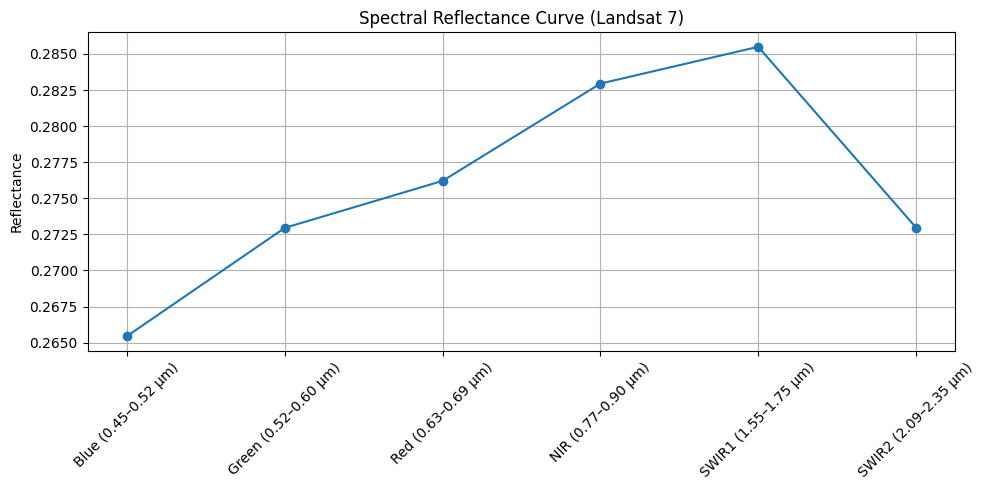

In [13]:
# Extract and scale values
mean_values = mean_dict.getInfo()
reflectance = [mean_values[b] * scale_factor for b in bands]

# Plot the spectral curve
plt.figure(figsize=(10, 5))
plt.plot(list(band_names.values()), reflectance, marker='o', linestyle='-')
plt.title('Spectral Reflectance Curve (Landsat 7)')
plt.ylabel('Reflectance')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

(6) If we want to apply multiple reducers to the same inputs what is a more efficient way to do so than just writing out a long series of sequential reducers on our end? (2 pts)

# Cloud cover

(7) Produce a table that tells me the average amount of cloud cover per LandSat image in a year: for 2005, 2010 and 2015. Do this over a region of your choice, as a percentage. Provide a notebook example of your code that does so, in addition to your table. (5 pts)

**Code for Q7**

**Approach:**


* Landsat 7 C2 L2 imagery is filtered to the year of interest and the regions intersecting the ROI.
* For each image, the QA_PIXELS band is used to find pixels flagged as cloud (bit 3). Create a binary cloud mask where cloud pixels are 1 and non-cloud pixels are 0.
* The mean of this binary mask then gives the fraction of cloudy pixels for each image.
* This is converted to a percentage, stored as an image property of an image, and averaged across all images for the years of interest.

In [14]:
# Define a 5km ROI around Munich, Germany
point_q7 = ee.Geometry.Point([11.576, 48.137])
region_q7 = point_q7.buffer(5000).bounds()

# Load Landsat 7 Collection 2 Level 2
landsat_q7 = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2')

The function below is applied to each image and calculates the cloud cover percentage. In QA_PIXEL, bit 3 represents cloud. Cloudy pixels are assigned 1 and all other pixels are assigned 0. Applying `ee.Reducer.mean()` to this binary image returns the proportion of cloudy pixels within the ROI. `.get()` is used instead of `.getInfo()` to get the cloud fraction as an EE object for the later use of `.map()`.

In [15]:
def add_cloud_percentage(image):
    # Select the Landsat Quality-Assurance band
    qa = image.select('QA_PIXEL')

    # QA_PIXEL bit 3 are cloud pixels
    cloud = qa.bitwiseAnd(1 << 3).neq(0)

    # Cloud pixels = 1 and Clear pixels = 0
    # The mean gives "number of cloud pixels" / "number of all pixels" within the ROI
    cloud_fraction = cloud.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region_q7,
        scale=30,
        maxPixels=1e9
    ).get('QA_PIXEL')

    # Convert the cloud fraction to percentage
    cloud_cover_pct = ee.Number(cloud_fraction).multiply(100)

    # Set percentage as an image property for each image to calculate annual means
    return image.set('cloud_cover_pct', cloud_cover_pct)

The analysis is repeated for 2005, 2010 and 2015 in a loop. For each year, the ImageCollection is filtered and the cloud-percentage function is applied to every image using `.map()`. `filterBounds()` here restricts the collection to images intersecting the ROI, while the `reduceRegion()` inside the function above performs the actual cloud calculation within the ROI. The resulting `cloud_cover_pct` image properties are then averaged with `aggregate_mean()`.

In [16]:
# Years of interest
years = [2005, 2010, 2015]

results = []

# Loop through the years list
for year in years:

    # Filter images for the current year and apply add_cloud_percentage
    yearly_collection = (
        landsat_q7
        .filterBounds(region_q7)
        .filterDate(f'{year}-01-01', f'{year + 1}-01-01')
        .map(add_cloud_percentage)
    )

    # Calculate mean cloud cover across all images in the year
    average_cloud = yearly_collection.aggregate_mean('cloud_cover_pct').getInfo()

    # Record image count to show the number of observations contributing to each mean
    image_count = yearly_collection.size().getInfo()

    # Store annual results
    results.append({
        'Year': year,
        'Average Cloud Cover (%)': average_cloud,
        'Number of Images': image_count
    })

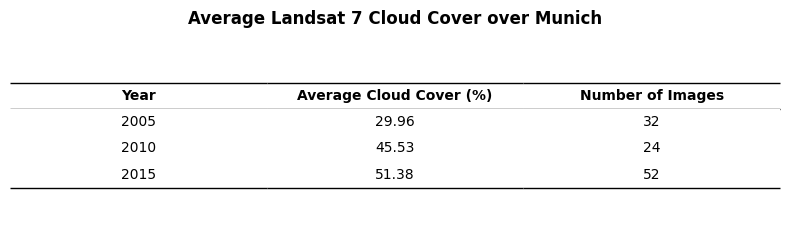

In [17]:
# Prepare values for the table
table_data = [
    [
        result['Year'],
        f"{result['Average Cloud Cover (%)']:.2f}",
        result['Number of Images']
    ]
    for result in results
]

column_labels = [
    'Year',
    'Average Cloud Cover (%)',
    'Number of Images'
]

# Create figure
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.axis('off')

# Add table to figure
table = ax.table(
    cellText=table_data,
    colLabels=column_labels,
    cellLoc='center',
    colLoc='center',
    loc='center'
)

# Format table
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

for cell in table.get_celld().values():
    cell.set_linewidth(0)

for col in range(len(column_labels)):
    header = table[(0, col)]
    header.set_text_props(weight='bold')
    header.visible_edges = 'TB'
    header.set_linewidth(1)

last_row = len(table_data)

for col in range(len(column_labels)):
    cell = table[(last_row, col)]
    cell.visible_edges = 'B'
    cell.set_linewidth(1)

ax.set_title(
    'Average Landsat 7 Cloud Cover over Munich',
    fontsize=12,
    fontweight='bold',
    pad=12
)

plt.tight_layout()
plt.show()

# Final exercise

(8) Exercise: Using Sentinel 2, create a figure that does the following over the city of Christchurch, NZ:

* Conduct a basic quality assessment of the data you use by stating how much of your area is covered by cloud.
* Show the spectral reflectance signatures of: urban, forest, grassland, water and bare soil. Using a line graph that stacks them all onto the same axes.
* Gives examples of the sample areas that you have used to create these spectral signatures.

Provide a publication quality copy of this figure in the answer proforma. Publication quality means that:
1. It is at a good quality (resolution) and not blurry.
2. The font size of all elements is big enough to read easily on a screen when placed in the document.
3. as a figure caption that ensures the reader knows what you have done and why.
4. Tells the story 'at a glance'. Don't make your viewer work too hard to understand your core message. (25 pts)

**Code for Q8**

**Approach:**
* Defining ROI and dataset selection
* Cloud quality assessment
* Defining sample areas for the land cover types
* Calculating the spectral signatures for each land cover types
* RGB image preparation
* Obtaining sample area coordinates for plotting
* Creating final figure with 2 panels

Sentinel-2 Level-2A Surface Reflectance data were selected because atmospherically corrected surface reflectance is appropriate for comparing the spectral characteristics of different land cover types.

In [18]:
# Define a 10km ROI around Christchurch, New Zealand
point_q8 = ee.Geometry.Point([172.636, -43.532])
region_q8 = point_q8.buffer(10000).bounds()

# Load Sentinel-2 Level-2A SR image
image_q8 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(region_q8)
    .filterDate('2026-04-01', '2026-08-01')
    .sort('CLOUDY_PIXEL_PERCENTAGE')
    .first()
)

Cloud cover quality assessment using the Scene Classification Layer (SCL)

A basic quality assessment is performed using the S2 SCL. Classes 8, 9 and 10 are Clouds Medium Probability, Clouds High Probability and Cirrus respectively, and combined to identify cloud pixels. The mean of this binary mask within the ROI gives the fraction of cloud pixels for the percentage calculation.

In [19]:
# Sentinel-2 SCL
scl = image_q8.select('SCL')

# SCL classes {8: Cloud Medium Probability, 9: Cloud High Probability, 10: Cirrus}
cloud_pixels_q8 = (
    scl.eq(8).Or(scl.eq(9)).Or(scl.eq(10))
)

# The mean gives "number of cloud pixels" / "number of all pixels" within the ROI
cloud_fraction_q8 = cloud_pixels_q8.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=region_q8,
    scale=20,
    maxPixels=1e9
).get('SCL')

cloud_cover_pct_q8 = ee.Number(cloud_fraction_q8).multiply(100).getInfo()

print(f'Cloud cover percentage within Christchurch ROI: {cloud_cover_pct_q8:.4f}%')



Cloud cover percentage within Christchurch ROI: 0.0116%


Defining sample points for sample areas.

Representative locations are selected for the land cover types: urban, forest, grassland, water and bare soil. The locations are selected by visually identifying representative examples of each land cover type via satellite images.

In [20]:
# Define sample points within the ROI
urban_point = ee.Geometry.Point([172.636000, -43.532000])
forest_point = ee.Geometry.Point([172.687333, -43.462798])
grassland_point = ee.Geometry.Point([172.622216, -43.535693])
water_point = ee.Geometry.Point([172.710813, -43.529355])
bare_soil_point = ee.Geometry.Point([172.658534, -43.546858])

# Define sample areas within the ROI
urban_region = urban_point.buffer(100).bounds()
forest_region = forest_point.buffer(100).bounds()
grassland_region = grassland_point.buffer(100).bounds()
water_region = water_point.buffer(100).bounds()
bare_soil_region = bare_soil_point.buffer(100).bounds()

Defining Sentinel-2 spectral bands and scaling factor

10 bands spanning the visible, red-edge, NIR and SWIR regions are selected to characterise differences between the land cover types that respond differently across the EM spectrum. S2 SR values have a scale factor of 0.0001.

In [21]:
# Define Sentinel-2 spectral bands
bands_q8 = [
    'B2', 'B3', 'B4',
    'B5', 'B6', 'B7',
    'B8', 'B8A',
    'B11', 'B12'
]

band_names_q8 = {
    'B2': 'Blue (497 nm)',
    'B3': 'Green (560 nm)',
    'B4': 'Red (665 nm)',
    'B5': 'Red Edge 1 (704 nm)',
    'B6': 'Red Edge 2 (740 nm)',
    'B7': 'Red Edge 3 (783 nm)',
    'B8': 'NIR (835 nm)',
    'B8A': 'Red Edge 4 (865 nm)',
    'B11': 'SWIR1 (1614 nm)',
    'B12': 'SWIR2 (2202 nm)'
}

scale_factor_q8 = 1e-4

The function below calculates the spectral signature for each sample area. The mean surface reflectance is calculated independently for every selected band using `ee.Reducer.mean()`.



In [22]:
def get_spectral_signature(region):
    mean_dict = image_q8.select(bands_q8).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region,
        scale=20,
        maxPixels=1e6
    ).getInfo()

    # Scale extracted values
    reflectance = [mean_dict[b] * scale_factor_q8 for b in bands_q8]

    return reflectance

In [23]:
urban_reflectance = get_spectral_signature(urban_region)
forest_reflectance = get_spectral_signature(forest_region)
grassland_reflectance = get_spectral_signature(grassland_region)
water_reflectance = get_spectral_signature(water_region)
bare_soil_reflectance = get_spectral_signature(bare_soil_region)

labels_q8 = list(band_names_q8.values())

Creating the Sentinel-2 true colour image using the RGB bands. A smaller preview extent centred on the sample locations is used for the final figure for more clear view.



In [24]:
# Smaller region for figure preview only
preview_point_q8 = ee.Geometry.Point([172.665626, -43.498780])
preview_region_q8 = preview_point_q8.buffer(6500).bounds()

thumb_params_q8 = {
    'dimensions': 800,
    'region': preview_region_q8,
    'format': 'png',
    'bands': ['B4', 'B3', 'B2'],
    'min': 0,
    'max': 4000,
    'gamma': 1.2
}

url_q8 = image_q8.getThumbURL(thumb_params_q8)

This function converts the EE geometries to longitude and latitude bounds in order to position them on the figure. Bounds are extracted for each sample area, allowing the sample regions to be displayed as labelled boxes.

In [25]:
def get_bounds_coords(bounds):
    coords = bounds.coordinates().getInfo()[0]
    lons = [pt[0] for pt in coords]
    lats = [pt[1] for pt in coords]
    return min(lons), max(lons), min(lats), max(lats)

In [26]:
xmin, xmax, ymin, ymax = get_bounds_coords(preview_region_q8)

sample_regions = {
    'Urban': urban_region,
    'Forest': forest_region,
    'Grassland': grassland_region,
    'Water': water_region,
    'Bare soil': bare_soil_region
}

sample_bounds = {
    name: get_bounds_coords(region)
    for name, region in sample_regions.items()
}

Creating the final figure.

The final figure combines the spatial and spectral results in two panels. The upper panel shows the S2 true colour image with the 5 sample areas identified. The cloud coverage percentage over the ROI is also included.

The lower panel displays the line graph of the spectral reflectance signatures of all 5 land cover types across the selected bands.

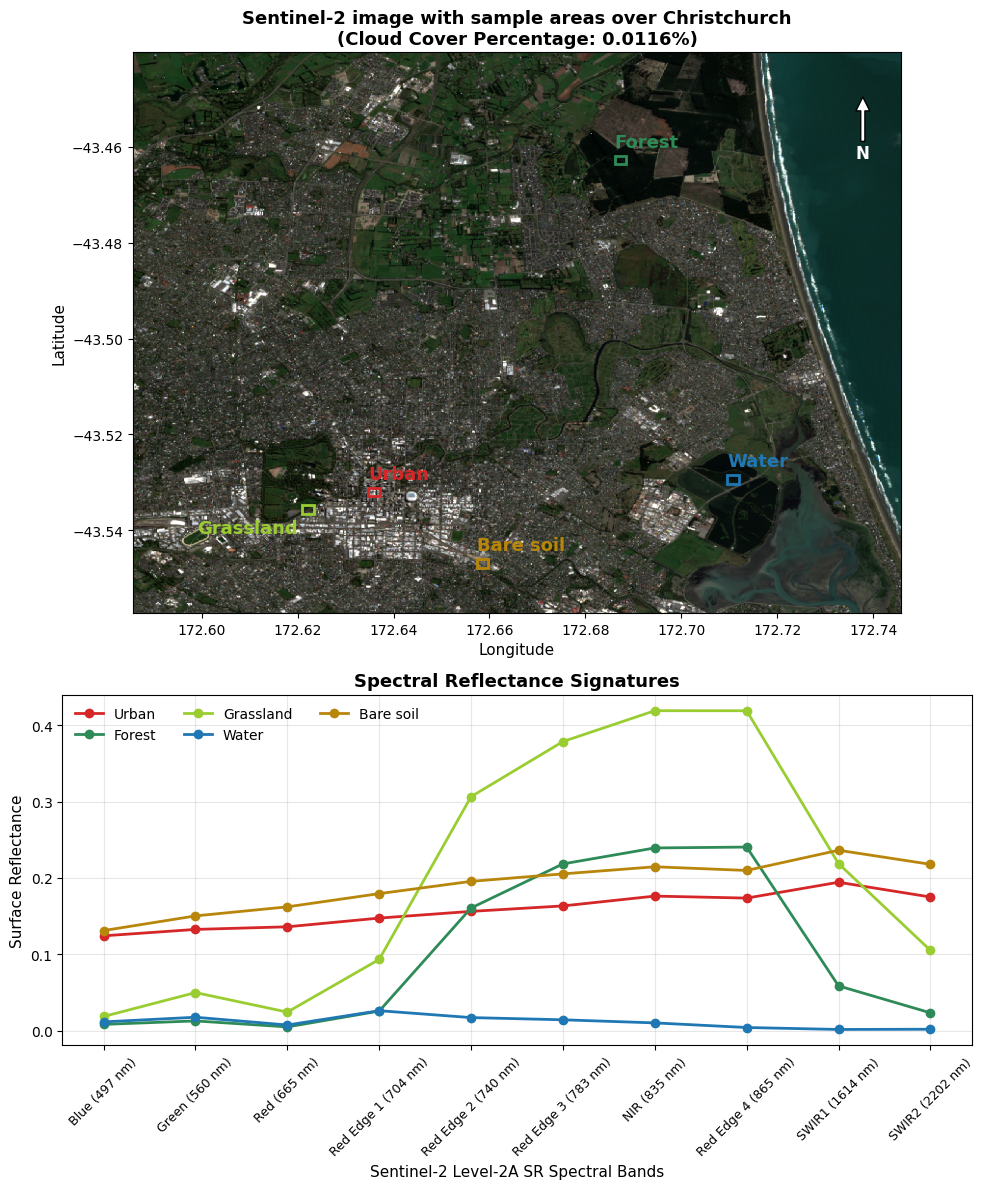

In [27]:
# Colours shared between map samples and spectral curves
sample_colors = {
    'Urban': 'tab:red',
    'Forest': 'seagreen',
    'Grassland': 'yellowgreen',
    'Water': 'tab:blue',
    'Bare soil': 'darkgoldenrod'
}

# Map reflectance data
reflectance_data = {
    'Urban': urban_reflectance,
    'Forest': forest_reflectance,
    'Grassland': grassland_reflectance,
    'Water': water_reflectance,
    'Bare soil': bare_soil_reflectance
}

# Create figure
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 12),
    gridspec_kw={'height_ratios': [1.6, 1]}
)

# Download Sentinel-2 RGB thumbnail
with tempfile.NamedTemporaryFile(suffix='.png') as f:
    urllib.request.urlretrieve(url_q8, f.name)
    img = mpimg.imread(f.name)

    ax1.imshow(
        img,
        extent=[xmin, xmax, ymin, ymax]
    )

# Add sample boxes
for name, bounds in sample_bounds.items():
    rxmin, rxmax, rymin, rymax = bounds

    rect = patches.Rectangle(
        (rxmin, rymin),
        rxmax - rxmin,
        rymax - rymin,
        linewidth=2,
        edgecolor=sample_colors[name],
        facecolor='none'
    )

    ax1.add_patch(rect)

    # Add sample label
    if name == 'Grassland':
        label_x = rxmin - 0.001
        label_y = rymin - 0.001
        ha = 'right'
        va = 'top'
    else:
        label_x = rxmin
        label_y = rymax + 0.001
        ha = 'left'
        va = 'bottom'

    ax1.text(
        label_x,
        label_y,
        name,
        color=sample_colors[name],
        fontsize=13,
        fontweight='bold',
        horizontalalignment=ha,
        verticalalignment=va
    )

# Add north arrow
ax1.annotate(
    'N',
    xy=(0.95, 0.92),
    xytext=(0.95, 0.82),
    xycoords='axes fraction',
    ha='center',
    va='center',
    fontsize=12,
    fontweight='bold',
    color='white',
    arrowprops=dict(
        facecolor='white',
        edgecolor='black',
        width=3,
        headwidth=10,
        headlength=10
    )
)

# Set figure title
ax1.set_title(
    f'Sentinel-2 image with sample areas over Christchurch\n'
    f'(Cloud Cover Percentage: {cloud_cover_pct_q8:.4f}%)',
    fontsize=13,
    fontweight='bold'
)

ax1.set_xlabel('Longitude', fontsize=11)
ax1.set_ylabel('Latitude', fontsize=11)
ax1.tick_params(labelsize=10)

# Plot all spectral signatures on same axes
for name, values in reflectance_data.items():
    ax2.plot(
        range(len(labels_q8)),
        values,
        marker='o',
        linewidth=2,
        label=name,
        color=sample_colors[name]
    )

ax2.set_xticks(range(len(labels_q8)))
ax2.set_xticklabels(
    labels_q8,
    rotation=45,
    fontsize=9
)

ax2.set_ylabel('Surface Reflectance', fontsize=11)
ax2.set_xlabel('Sentinel-2 Level-2A SR Spectral Bands', fontsize=11)
ax2.set_title('Spectral Reflectance Signatures', fontsize=13, fontweight='bold')

ax2.tick_params(axis='y', labelsize=10)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10, ncol=3, frameon=False)

plt.tight_layout()
plt.show()